In [1]:
import time

import numpy as np
import matplotlib.pyplot as plt
from typing import List
import pysr

import sympy
import numpy as np
from matplotlib import pyplot as plt
from pysr import PySRRegressor
from sklearn.model_selection import train_test_split

# Configure plot defaults
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["grid.color"] = "#666666"

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


If you not yet downloaded the files

In [2]:
# !git clone git@github.com:jibanCat/InferenceLyaData.git

In [3]:
import h5py

In [21]:
with h5py.File(
    "../InferenceLyaData/1pvar/lf_ns_npoints50_datacorrFalse.hdf5", "r"
) as file:
    print(file.keys())

    flux_vectors = file["flux_vectors"][:]
    kfkms = file["kfkms"][:]
    # kfmpc = file["kfmpc"][:]
    zout = file["zout"][:]

    params = file["params"][:]

kfkms.shape, flux_vectors.shape, zout.shape, params.shape

<KeysViewHDF5 ['flux_vectors', 'kfkms', 'loo_error', 'params', 'zout']>


((50, 13, 35), (50, 13, 35), (13,), (50, 11))

In [31]:
# take z = 3.6
z = 3.6
zindex = np.where(zout == z)[0][0]  # index of z = 5
print(zindex)

# take z=3.6, and flatten the flux vectors, such that the dim=1 is p1d values per k and parameter
flux_vectors_z = flux_vectors[:, zindex, :]
flux_vectors_z = flux_vectors_z.flatten()[:, np.newaxis]  # add a new axis to make it 2D
print(flux_vectors_z.shape)

# do the same for kfkms
kfkms_z = kfkms[:, zindex, :]
kfkms_z = kfkms_z.flatten()[:, np.newaxis]  # add a new axis to make it 2D
print(kfkms_z.shape)

# do the same for the parameter input
# np is index=2
params_values = params[:, 2]
# repeat this for the number of kfkms
params_values = np.repeat(params_values[:, np.newaxis], kfkms.shape[2], axis=1)
params_values = params_values.flatten()[:, np.newaxis]  # add a new axis to make it 2D
print(params_values.shape)

5
(1750, 1)
(1750, 1)
(1750, 1)


Preprocessing for the fit

In [37]:
# Shapes: (1750, 1)
X_param = params_values
X_k = kfkms_z
y = flux_vectors_z

# Concatenate inputs to form design matrix
X = np.hstack([X_param, X_k])  # shape: (1750, 2)

In [49]:
from pysr import PySRRegressor

model = PySRRegressor(
    model_selection="best",
    niterations=20,  # increase for better expressions
    binary_operators=["+", "*", "-", "/"],
    unary_operators=[
        "sin", "cos", "exp", "log", "square", "sqrt", "inv(x) = 1/x"
    ],
    extra_sympy_mappings={"inv": lambda x: 1 / x},
    loss="loss(x, y) = (x - y)^2",
    maxsize=20,
    maxdepth=10,
    verbosity=1,
    random_state=42,
)

model.fit(X, y)

/Users/jibanmac/Documents/conda/emu-3.9/lib/python3.9/site-packages/pysr/sr.py:915: FutureWarning: `loss` has been renamed to `elementwise_loss` in PySRRegressor. Please use that instead.
  warnings.warn(
/Users/jibanmac/Documents/conda/emu-3.9/lib/python3.9/site-packages/pysr/sr.py:1310: UserWarning: Note: Setting `random_state` without also setting `deterministic` to True and `procs` to 0 will result in non-deterministic searches. 
  warnings.warn(
/Users/jibanmac/Documents/conda/emu-3.9/lib/python3.9/site-packages/pysr/sr.py:2582: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/Users/jibanmac/Documents/conda/emu-3.9/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
[ Info: Starte

PySRRegressor.equations_ = [
	    pick         score                                           equation  \
	0         0.000000e+00                                           sqrt(x1)   
	1         4.136067e-01                             0.008654212 + sqrt(x1)   
	2         3.617742e-03                       sin(sqrt(x1)) - -0.008848136   
	3         4.067734e-01                          sqrt(x1 * x0) * 1.1270891   
	4         1.765348e-02                     sin(sqrt(x1 * x0) * 1.1270891)   
	5         3.004922e-02                   (1.1270891 - x1) * sqrt(x1 * x0)   
	6         8.106098e-02              sqrt(x1) / (sin(1.0584747 / x0) + x1)   
	7   >>>>  3.030825e-01   ((sqrt(x1) * sqrt(x0)) - x1) / square(0.8838654)   
	8         1.086064e-02  (sin(sqrt(x1) * sqrt(x0)) - x1) / square(0.883...   
	9         2.447586e-03  sin(((sin(sqrt(x1)) * sqrt(x0)) - x1) / square...   
	10        6.634128e-05  ((sin(sqrt(x1) / sqrt(x0)) * x0) - x1) / squar...   
	11        5.260648e-03  ((sin(sin(sqrt(x1) / sqrt(x0))) * x0) - x1) / ...   
	12        1.625678e-07  ((sin(sin(sqrt(x1) / sqrt(x0))) * x0) - x1) / ...   
	13        6.712958e-03  sin((square(1.0579468 - -0.08968036) * sqrt(x0...   
	14        1.319641e-02  sin((square(1.0579468 - -0.08968036) * sqrt(x0...   
	15        1.853736e-02  sin((sqrt(x0) * square(1.0579468 - -0.08968036...   
	
	        loss  complexity  
	0   0.000133           2  
	1   0.000058           4  
	2   0.000058           5  
	3   0.000039           6  
	4   0.000038           7  
	5   0.000037           8  
	6   0.000034           9  
	7   0.000025          10  
	8   0.000025          11  
	9   0.000025          12  
	10  0.000025          13  
	11  0.000025          14  
	12  0.000025          16  
	13  0.000024          17  
	14  0.000024          18  
	15  0.000024          19  
]

In [50]:
# print(model)
model.equations_  # to see all candidate expressions

,complexity,loss,score,equation,sympy_format,lambda_format
0,2,0.000133,0.000000e+00,sqrt(x1),sqrt(x1),PySRFunction(X=>sqrt(x1))
1,4,0.000058,4.136067e-01,0.008654212 + sqrt(x1),sqrt(x1) + 0.008654212,PySRFunction(X=>sqrt(x1) + 0.008654212)
2,5,0.000058,3.617742e-03,sin(sqrt(x1)) - -0.008848136,sin(sqrt(x1)) + 0.008848136,PySRFunction(X=>sin(sqrt(x1)) + 0.008848136)
3,6,0.000039,4.067734e-01,sqrt(x1 * x0) * 1.1270891,1.1270891*sqrt(x0*x1),PySRFunction(X=>1.1270891*sqrt(x0*x1))
4,7,0.000038,1.765348e-02,sin(sqrt(x1 * x0) * 1.1270891),sin(1.1270891*sqrt(x0*x1)),PySRFunction(X=>sin(1.1270891*sqrt(x0*x1)))
5,8,0.000037,3.004922e-02,(1.1270891 - x1) * sqrt(x1 * x0),sqrt(x0*x1)*(1.1270891 - x1),PySRFunction(X=>sqrt(x0*x1)*(1.1270891 - x1))
6,9,0.000034,8.106098e-02,sqrt(x1) / (sin(1.0584747 / x0) + x1),sqrt(x1)/(x1 + sin(1.0584747/x0)),PySRFunction(X=>sqrt(x1)/(x1 + sin(1.0584747/x...
7,10,0.000025,3.030825e-01,((sqrt(x1) * sqrt(x0)) - x1) / square(0.8838654),1.28005235669386*sqrt(x0)*sqrt(x1) - 1.2800523...,PySRFunction(X=>1.28005235669386*sqrt(x0)*sqrt...
8,11,0.000025,1.086064e-02,(sin(sqrt(x1) * sqrt(x0)) - x1) / square(0.883...,-1.28005235669386*x1 + 1.28005235669386*sin(sq...,PySRFunction(X=>-1.28005235669386*x1 + 1.28005...
9,12,0.000025,2.447586e-03,sin(((sin(sqrt(x1)) * sqrt(x0)) - x1) / square...,sin(1.28005235669386*sqrt(x0)*sin(sqrt(x1)) - ...,PySRFunction(X=>sin(1.28005235669386*sqrt(x0)*...


/Users/jibanmac/Documents/conda/emu-3.9/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/jibanmac/Documents/conda/emu-3.9/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


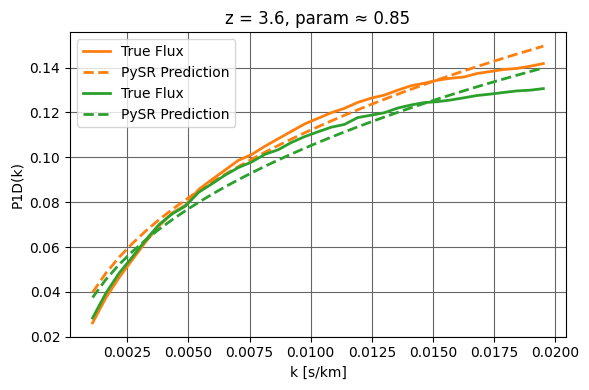

In [51]:
import numpy as np
import matplotlib.pyplot as plt

# Choose a parameter value to fix
param_fixed = 0.95306122  # can be any float within the param range

# Get unique k values from your data
k_values = np.unique(X[:, 1])

# Construct input (param_fixed, k) pairs
X_pred = np.column_stack([
    np.full_like(k_values, fill_value=param_fixed),
    k_values
])

# Get model prediction
flux_pred = model.predict(X_pred)

# To compare with ground truth, find the closest match in your original param list
# (Assumes you used params[:,2] to construct your X)
param_list = np.unique(X[:, 0])
idx_closest = np.argmin(np.abs(param_list - param_fixed))
param_closest = param_list[idx_closest]

# Now find all rows in X with that param value
mask = X[:, 0] == param_closest
k_true = X[mask, 1]
flux_true = y[mask, 0]  # shape: (N,)

# Sort both by k to ensure aligned plotting
sort_idx_true = np.argsort(k_true)
sort_idx_pred = np.argsort(k_values)

# Plot
plt.figure(figsize=(6, 4))
plt.plot(k_true[sort_idx_true], flux_true[sort_idx_true], label="True Flux", lw=2, color="C1")
plt.plot(k_values[sort_idx_pred], flux_pred[sort_idx_pred], label="PySR Prediction", lw=2, linestyle="--", color="C1")

############### Another param ###############
# Choose a parameter value to fix
param_fixed = 0.85  # can be any float within the param range

# Get unique k values from your data
k_values = np.unique(X[:, 1])

# Construct input (param_fixed, k) pairs
X_pred = np.column_stack([
    np.full_like(k_values, fill_value=param_fixed),
    k_values
])

# Get model prediction
flux_pred = model.predict(X_pred)

# To compare with ground truth, find the closest match in your original param list
# (Assumes you used params[:,2] to construct your X)
param_list = np.unique(X[:, 0])
idx_closest = np.argmin(np.abs(param_list - param_fixed))
param_closest = param_list[idx_closest]

# Now find all rows in X with that param value
mask = X[:, 0] == param_closest
k_true = X[mask, 1]
flux_true = y[mask, 0]  # shape: (N,)

# Sort both by k to ensure aligned plotting
sort_idx_true = np.argsort(k_true)
sort_idx_pred = np.argsort(k_values)

# Plot
plt.plot(k_true[sort_idx_true], flux_true[sort_idx_true], label="True Flux", lw=2, color="C2")
plt.plot(k_values[sort_idx_pred], flux_pred[sort_idx_pred], label="PySR Prediction", lw=2, linestyle="--", color="C2")


plt.xlabel("k [s/km]")
plt.ylabel("P1D(k)")
plt.title(f"z = 3.6, param ≈ {param_fixed:.2f}")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()